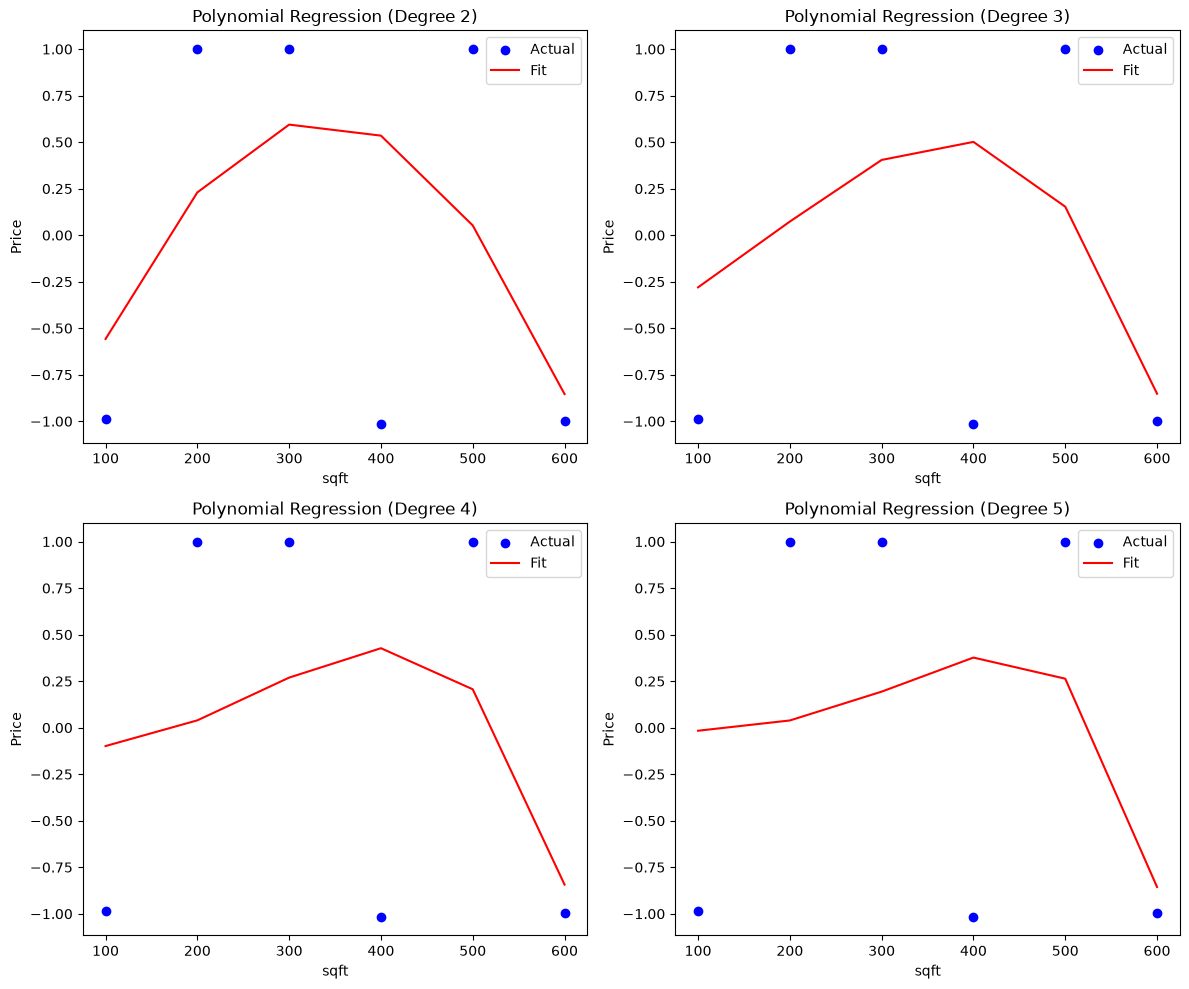

[[0.40427741]]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

X = pd.DataFrame([100, 200, 300, 400, 500, 600], columns=['sqft'])
y = pd.DataFrame([543543, 34543543, 34543345, 34534, 34543534, 345345], columns=['Price'])
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y)  # Normalize to mean=0, std=1

models = {}  # Store each model

# Create 2x2 subplots (for degrees 2, 3, 4, 5)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten to 1D for easier indexing

for idx, i in enumerate([2, 3, 4, 5]):
    # Create and fit polynomial
    poly = PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(X)
    
    lin = LinearRegression()
    lin.fit(X_poly, y_scaled)
    
    # Store model
    models[f'degree_{i}'] = {'model': lin, 'poly': poly}
    
    # Plot on specific subplot
    axes[idx].scatter(X, y_scaled, color='blue', label='Actual')
    axes[idx].plot(X, lin.predict(X_poly), color='red', label='Fit')
    axes[idx].set_title(f'Polynomial Regression (Degree {i})')
    axes[idx].set_xlabel('sqft')
    axes[idx].set_ylabel('Price')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Access any model later
print(models['degree_3']['model'].predict([[1, 300, 300**2, 300**3]]))